# Разведочный анализ данных: предсказание цены подержанного транспорта

Задача — регрессия: по характеристикам объявления предсказать цену продажи `Selling_Price`.

Источник: [Car Price Prediction (used cars)](https://www.kaggle.com/datasets/vijayaadithyanvg/car-price-predictionused-cars/data).

Все цены в датасете указаны в **лакхах индийских рупий** (1 лакх = 100 000 ₹).

## Библиотеки

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import pickle

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

# 1. Загрузка данных и знакомство с ними

In [2]:
df = pd.read_csv('../data/car_data.csv')
print('Размер датасета:', df.shape)
df.head()

Размер датасета: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Year,301.0,2013.627907,2.891554,2003.00,2012.0,2014.0,2016.0,2018.0
Selling_Price,301.0,4.661296,5.082812,0.10,0.9,3.6,6.0,35.0
Present_Price,301.0,7.628472,8.644115,0.32,1.2,6.4,9.9,92.6
Kms_Driven,301.0,36947.205980,38886.883882,500.00,15000.0,32000.0,48767.0,500000.0
Owner,301.0,0.043189,0.247915,0.00,0.0,0.0,0.0,3.0


Датасет содержит 301 объявление о продаже и 9 столбцов — 8 признаков и целевая переменная:

| Признак | Тип | Описание |
|---|---|---|
| `Car_Name` | категориальный | название модели |
| `Year` | числовой | год выпуска |
| `Present_Price` | числовой | цена нового экземпляра сегодня, лакхов ₹ |
| `Kms_Driven` | числовой | пробег, км |
| `Fuel_Type` | категориальный | тип топлива: Petrol / Diesel / CNG |
| `Seller_Type` | категориальный | продавец: Dealer (салон) / Individual (частник) |
| `Transmission` | категориальный | коробка передач: Manual / Automatic |
| `Owner` | категориальный | число предыдущих владельцев |
| `Selling_Price` | **целевая** | запрашиваемая цена, лакхов ₹ |

In [5]:
numeric_features = ['Year', 'Present_Price', 'Kms_Driven']
categorical_features = ['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner']
target = 'Selling_Price'

# Русские названия признаков — используются в подписях графиков и таблиц
FEATURE_RU = {
    'Car_Name': 'модель',
    'Year': 'год выпуска',
    'Selling_Price': 'цена продажи',
    'Present_Price': 'цена нового',
    'Kms_Driven': 'пробег',
    'Fuel_Type': 'тип топлива',
    'Seller_Type': 'тип продавца',
    'Transmission': 'коробка передач',
    'Owner': 'число владельцев',
    'vehicle_type': 'тип транспорта',
    'car_age': 'возраст',
    'kms_per_year': 'пробег в год',
    'depreciation': 'сохранность стоимости',
}


def ru(col):
    """Название признака с переводом: 'Kms_Driven (пробег)'."""
    return f'{col} ({FEATURE_RU[col]})' if col in FEATURE_RU else col


def ru_frame(obj, axis='index'):
    """Копия таблицы с переведёнными названиями строк или столбцов."""
    return obj.rename(**{axis: ru})


print('Числовых признаков:', len(numeric_features))
print('Категориальных признаков:', len(categorical_features))
print()
print('Расшифровка названий:')
for col in numeric_features + categorical_features + [target]:
    print(f'  {col:<14} — {FEATURE_RU[col]}')


Числовых признаков: 3
Категориальных признаков: 5

Расшифровка названий:
  Year           — год выпуска
  Present_Price  — цена нового
  Kms_Driven     — пробег
  Car_Name       — модель
  Fuel_Type      — тип топлива
  Seller_Type    — тип продавца
  Transmission   — коробка передач
  Owner          — число владельцев
  Selling_Price  — цена продажи


In [6]:
print('Пропуски по столбцам:')
print(df.isna().sum().to_string())

Пропуски по столбцам:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0


In [7]:
for col in categorical_features:
    print(f'{ru(col)}: {df[col].nunique()} уникальных значений')
    if df[col].nunique() <= 10:
        print(df[col].value_counts().to_string())
    print()

Car_Name (модель): 98 уникальных значений

Fuel_Type (тип топлива): 3 уникальных значений
Fuel_Type
Petrol    239
Diesel     60
CNG         2

Seller_Type (тип продавца): 2 уникальных значений
Seller_Type
Dealer        195
Individual    106

Transmission (коробка передач): 2 уникальных значений
Transmission
Manual       261
Automatic     40

Owner (число владельцев): 3 уникальных значений
Owner
0    290
1     10
3      1



In [8]:
print('Целевая переменная:')
print(df[target].describe().round(2).to_string())
print()
print('Коэффициент асимметрии:', round(df[target].skew(), 2))

Целевая переменная:
count    301.00
mean       4.66
std        5.08
min        0.10
25%        0.90
50%        3.60
75%        6.00
max       35.00

Коэффициент асимметрии: 2.49


### Вывод

- Пропущенных значений нет, типы данных прочитаны корректно: три столбца `object`
  (`Car_Name`, `Fuel_Type`, `Seller_Type`, `Transmission`) и числовые остальные.
- `Car_Name` содержит 98 уникальных значений на 301 запись — в среднем по 3 объявления
  на модель. Как категориальный признак для модели он бесполезен (слишком высокая
  кардинальность), но его текст пригодится для анализа.
- Категория `CNG` в `Fuel_Type` представлена всего 2 записями, `Owner = 3` — одной.
  Это статистически незначимые группы.
- Целевая переменная сильно скошена вправо: медиана 3.6, среднее 4.66, максимум 35.0
  при коэффициенте асимметрии 2.49. Для линейных моделей потребуется логарифмирование.
- `Kms_Driven` имеет максимум 500 000 км при медиане около 32 000 — есть выбросы,
  которые нужно проверить на правдоподобие.

# 2. Очистка данных

## 2.1 Дубликаты

In [9]:
print('Полных дубликатов:', df.duplicated().sum())
df[df.duplicated(keep=False)].sort_values('Car_Name')

Полных дубликатов: 2


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
15,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
17,ertiga,2016,7.75,10.79,43000,Diesel,Dealer,Manual,0
51,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0
93,fortuner,2015,23.00,30.61,40000,Diesel,Dealer,Automatic,0


In [10]:
df = df.drop_duplicates().reset_index(drop=True)
print('После удаления дубликатов:', df.shape)

После удаления дубликатов: (299, 9)


## 2.2 Новый признак `vehicle_type`

При просмотре `Car_Name` обнаруживается, что датасет содержит не только автомобили:
в нём присутствуют мотоциклы и скутеры (Bajaj, Hero, TVS, Yamaha, Royal Enfield, KTM,
Honda Activa и т.д.). Это два принципиально разных рынка, и объединять их в одном
признаковом пространстве без пометки нельзя.

In [11]:
print(sorted(df[df['Present_Price'] < 1.0]['Car_Name'].unique()))

['Activa 3g', 'Activa 4g', 'Bajaj  ct 100', 'Bajaj Avenger 150', 'Bajaj Avenger 150 street', 'Bajaj Avenger 220', 'Bajaj Avenger 220 dtsi', 'Bajaj Avenger Street 220', 'Bajaj Discover 100', 'Bajaj Discover 125', 'Bajaj Pulsar  NS 200', 'Bajaj Pulsar 135 LS', 'Bajaj Pulsar 150', 'Bajaj Pulsar 220 F', 'Bajaj Pulsar NS 200', 'Hero  CBZ Xtreme', 'Hero  Ignitor Disc', 'Hero Extreme', 'Hero Glamour', 'Hero Honda CBZ extreme', 'Hero Honda Passion Pro', 'Hero Hunk', 'Hero Passion Pro', 'Hero Passion X pro', 'Hero Splender Plus', 'Hero Splender iSmart', 'Hero Super Splendor', 'Honda Activa 125', 'Honda Activa 4G', 'Honda CB Hornet 160R', 'Honda CB Shine', 'Honda CB Trigger', 'Honda CB Unicorn', 'Honda CB twister', 'Honda Dream Yuga ', 'Suzuki Access 125', 'TVS Apache RTR 160', 'TVS Apache RTR 180', 'TVS Jupyter', 'TVS Sport ', 'TVS Wego', 'Yamaha FZ  v 2.0', 'Yamaha FZ 16', 'Yamaha FZ S ', 'Yamaha FZ S V 2.0', 'Yamaha Fazer ']


In [12]:
TWO_WHEELER = (
    'bajaj|hero|tvs|yamaha|royal enfield|ktm|activa|'
    'honda cb|honda dream|karizma|mojo|um renegade|suzuki access'
)

df['vehicle_type'] = np.where(
    df['Car_Name'].str.lower().str.contains(TWO_WHEELER),
    'two_wheeler', 'car',
)

print(df['vehicle_type'].value_counts().to_string())
print()
print('Диапазон Present_Price по типам транспорта:')
print(df.groupby('vehicle_type')['Present_Price'].agg(['min', 'max', 'mean']).round(2).to_string())

vehicle_type
car            199
two_wheeler    100

Диапазон Present_Price по типам транспорта:
               min   max   mean
vehicle_type                   
car           2.28  92.6  10.85
two_wheeler   0.32   2.4   0.97


Разделение по названию модели подтверждается ценой: у двухколёсных `Present_Price`
не превышает 2.4 лакха, у автомобилей начинается от 2.28. Классы разделены корректно.

## 2.3 Проверка пробега на правдоподобие

In [13]:
df['car_age'] = 2020 - df['Year']
df['kms_per_year'] = (df['Kms_Driven'] / df['car_age'].clip(lower=1)).round(0)

df.nlargest(6, 'Kms_Driven')[
    ['Car_Name', 'vehicle_type', 'Year', 'Kms_Driven', 'kms_per_year', 'Selling_Price']
]

,Car_Name,vehicle_type,Year,Kms_Driven,kms_per_year,Selling_Price
194,Activa 3g,two_wheeler,2008,500000,41667.0,0.17
177,Honda Karizma,two_wheeler,2010,213000,21300.0,0.31
83,innova,car,2005,197176,13145.0,3.49
84,camry,car,2006,142000,10143.0,2.50
76,corolla,car,2004,135154,8447.0,1.50
52,fortuner,car,2013,135000,19286.0,16.00


In [14]:
before = len(df)
df = df[~((df['vehicle_type'] == 'two_wheeler') & (df['Kms_Driven'] > 100_000))]
print(f'Удалено записей: {before - len(df)}')
print('Размер выборки:', df.shape)

Удалено записей: 2
Размер выборки: (297, 12)


Формальный критерий «выброс = значение выше 1.5 IQR» здесь дал бы 8 записей к удалению,
но среди них Toyota Fortuner с пробегом 135 000 км и Toyota Innova с 197 000 км —
для дизельных внедорожников 2012–2005 годов это совершенно нормальный пробег,
и удалять их было бы потерей полезных данных.

Поэтому удалены только физически неправдоподобные записи: скутер Honda Activa 3g
с пробегом 500 000 км (41 667 км в год) и мотоцикл Honda Karizma с 213 000 км.
Для техники этого класса такой ресурс недостижим — почти наверняка ошибка ввода.

**Итоговый размер выборки — 297 записей.**

## 2.4 Новый признак: коэффициент сохранения стоимости

In [15]:
df['depreciation'] = (df['Selling_Price'] / df['Present_Price']).round(3)
print(df['depreciation'].describe().round(3).to_string())
print()
print('Записей с depreciation > 1 (цена б/у выше цены нового):',
      (df['depreciation'] > 1).sum())

count    297.000
mean       0.636
std        0.202
min        0.105
25%        0.505
50%        0.655
75%        0.791
max        0.989

Записей с depreciation > 1 (цена б/у выше цены нового): 0


Признак `depreciation` показывает, какую долю от цены нового экземпляра сохранил
конкретный лот. Значений больше единицы нет — данные непротиворечивы.

> **Важно:** этот признак вычислен через целевую переменную, поэтому подавать его
> в модель нельзя — это утечка целевой переменной (target leakage). Он создан
> **только для разведочного анализа** и будет удалён перед сохранением выборки (см. раздел 4).

## 2.5 Приведение типов данных

In [16]:
df['Owner'] = df['Owner'].astype('int8')
df['car_age'] = df['car_age'].astype('int8')
df['Year'] = df['Year'].astype('int16')
df['Kms_Driven'] = df['Kms_Driven'].astype('int32')
df['kms_per_year'] = df['kms_per_year'].astype('int32')

for col in ['Fuel_Type', 'Seller_Type', 'Transmission', 'vehicle_type']:
    df[col] = df[col].astype('category')

df.info()

<class 'pandas.DataFrame'>
Index: 297 entries, 0 to 298
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Car_Name       297 non-null    str     
 1   Year           297 non-null    int16   
 2   Selling_Price  297 non-null    float64 
 3   Present_Price  297 non-null    float64 
 4   Kms_Driven     297 non-null    int32   
 5   Fuel_Type      297 non-null    category
 6   Seller_Type    297 non-null    category
 7   Transmission   297 non-null    category
 8   Owner          297 non-null    int8    
 9   vehicle_type   297 non-null    category
 10  car_age        297 non-null    int8    
 11  kms_per_year   297 non-null    int32   
 12  depreciation   297 non-null    float64 
dtypes: category(4), float64(3), int16(1), int32(2), int8(2), str(1)
memory usage: 19.3 KB


Строковые признаки переведены в тип `category` — это и экономит память, и явно
фиксирует, что признак номинальный. `Owner` оставлен целым числом малой разрядности:
он порядковый, и его естественный порядок стоит сохранить.

# 3. Анализ признаков для модели

## 3.1 Цена продажи против цены нового (интерактивный график)

График интерактивный: при наведении показывается модель и её характеристики,
клик по легенде скрывает категорию. Обе оси логарифмические — без этого
мотоциклы за 0.1 лакха и Land Cruiser за 35 сливаются в одну точку.

In [17]:
fig = px.scatter(
    df, x='Present_Price', y='Selling_Price',
    color='vehicle_type', size='Kms_Driven', size_max=22,
    hover_name='Car_Name',
    hover_data={'Year': True, 'Fuel_Type': True, 'Transmission': True,
                'Kms_Driven': ':,', 'depreciation': ':.2f'},
    log_x=True, log_y=True, opacity=.75,
    color_discrete_map={'car': '#1f77b4', 'two_wheeler': '#ff7f0e'},
    title='Цена продажи против цены нового экземпляра (логарифмические оси)',
    labels={'Present_Price': 'Present_Price (цена нового), лакхов ₹',
            'Selling_Price': 'Selling_Price (цена продажи), лакхов ₹',
            'vehicle_type': 'vehicle_type (тип транспорта)',
            'Kms_Driven': 'Kms_Driven (пробег)',
            'Fuel_Type': 'Fuel_Type (тип топлива)',
            'Transmission': 'Transmission (коробка передач)',
            'Year': 'Year (год выпуска)',
            'depreciation': 'depreciation (сохранность)'},
)
fig.update_layout(width=1100, height=650)

fig.write_html('price_scatter.html', include_plotlyjs='cdn')
fig.write_image('price_scatter.png', width=1100, height=650)
fig.show()

### Вывод

- Связь `Present_Price` → `Selling_Price` близка к линейной в логарифмических координатах
  и охватывает три порядка величины — это главный предиктор цены.
- Автомобили и двухколёсные образуют два непересекающихся облака: у двухколёсных
  `Present_Price` не превышает 2.4 лакха, у автомобилей не опускается ниже 2.28.
  Единая модель по сути будет решать две разные задачи, и признак `vehicle_type`
  даст ей эту информацию явно.
- Размер точки (пробег) не показывает очевидной связи с отклонением от линии тренда —
  значит пробег влияет на цену слабее, чем исходная стоимость модели.

## 3.2 Распределение целевой переменной

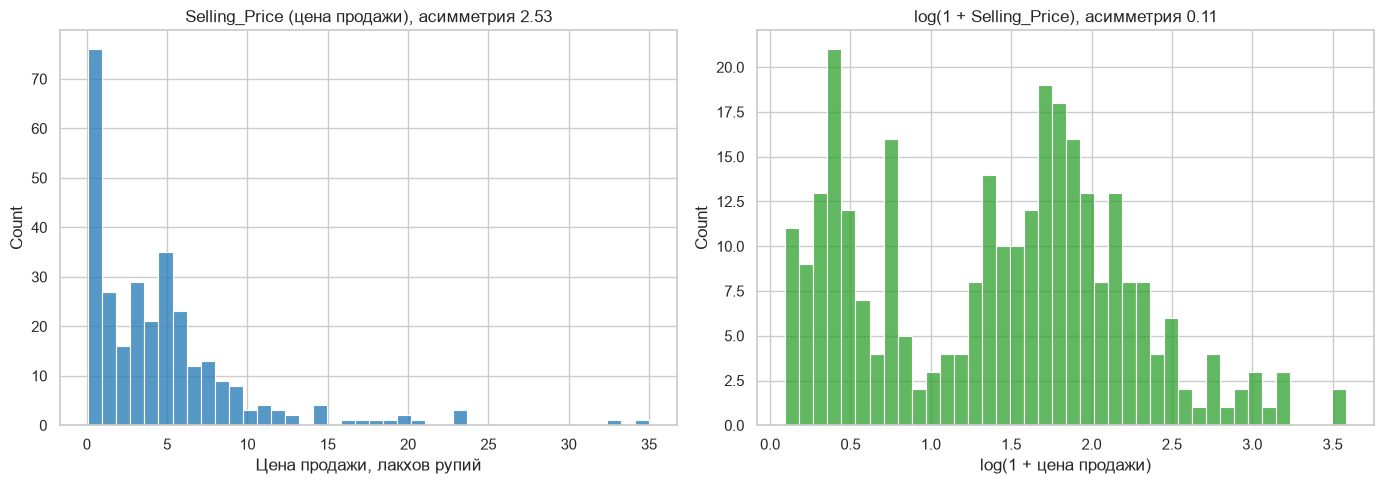

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(df[target], bins=40, ax=axes[0], color='#1f77b4')
axes[0].set_title(f'Selling_Price (цена продажи), асимметрия {df[target].skew():.2f}')
axes[0].set_xlabel('Цена продажи, лакхов рупий')

sns.histplot(np.log1p(df[target]), bins=40, ax=axes[1], color='#2ca02c')
axes[1].set_title(f'log(1 + Selling_Price), асимметрия {np.log1p(df[target]).skew():.2f}')
axes[1].set_xlabel('log(1 + цена продажи)')

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=120)
plt.show()

### Вывод

- Исходное распределение цены сильно скошено вправо (асимметрия 2.53): большинство
  лотов дешевле 6 лакхов, но есть хвост до 35.
- Логарифмирование приводит асимметрию к 0.11 — распределение становится почти
  симметричным, но двугорбым: левый горб — двухколёсные, правый — автомобили.
- Практический вывод: линейные модели и метрики вроде `MAE` стоит считать на
  логарифмированной цене, иначе дорогие лоты будут доминировать в функции потерь.

## 3.3 Корреляционная матрица

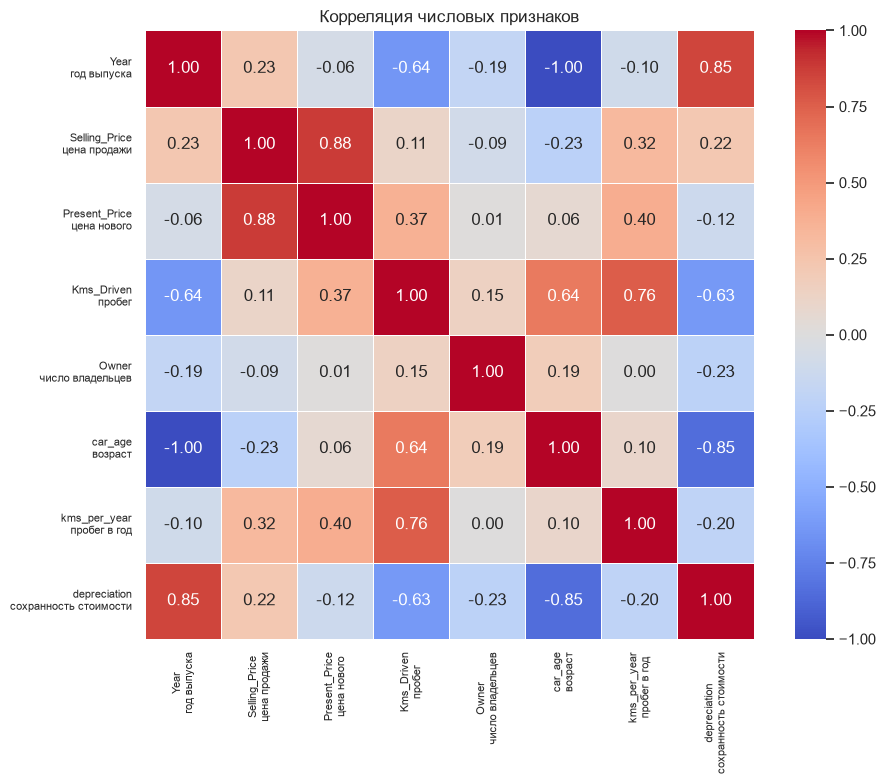

In [19]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)

# подписи осей в две строки: английское имя, под ним перевод
labels = [f'{c}\n{FEATURE_RU[c]}' for c in corr.columns]

sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=.5,
            xticklabels=labels, yticklabels=labels)
plt.xticks(fontsize=8)
plt.yticks(fontsize=8, rotation=0)
plt.title('Корреляция числовых признаков')
plt.tight_layout()
plt.savefig('correlation.png', dpi=120)
plt.show()

In [20]:
ru_frame(corr[target].drop(target).sort_values(key=abs, ascending=False).round(3))

Present_Price (цена нового)             0.876
kms_per_year (пробег в год)             0.321
Year (год выпуска)                      0.228
car_age (возраст)                      -0.228
depreciation (сохранность стоимости)    0.223
Kms_Driven (пробег)                     0.115
Owner (число владельцев)               -0.089
Name: Selling_Price, dtype: float64

### Вывод

- `Present_Price` доминирует: корреляция с целевой переменной 0.876, все остальные
  признаки — ниже 0.33 по модулю.
- `Kms_Driven` коррелирует с ценой слабо (0.115), а производный `kms_per_year` —
  заметно сильнее (0.321). Но знак здесь обманчив: связь положительная, то есть
  «больше ездят — дороже стоит». Причина не в пробеге, а в сегменте: годовой пробег
  сам коррелирует с `Present_Price` на 0.395 — дорогие машины просто больше ездят.
  Как этот эффект разделяется, разобрано в разделе 3.6.
- `Year` и `car_age` — это один и тот же признак с противоположным знаком
  (корреляция −1.00). В модель нужно подать только один из них.
- `Kms_Driven` и `car_age` связаны на 0.64 — ожидаемо, чем старше транспорт,
  тем больше накатано.
- `Present_Price` и `car_age` практически не связаны (0.06): возраст лота не говорит ничего
  о ценовом сегменте модели. Это хорошо — признаки несут независимую информацию.

## 3.4 Цена продажи в разрезе категориальных признаков

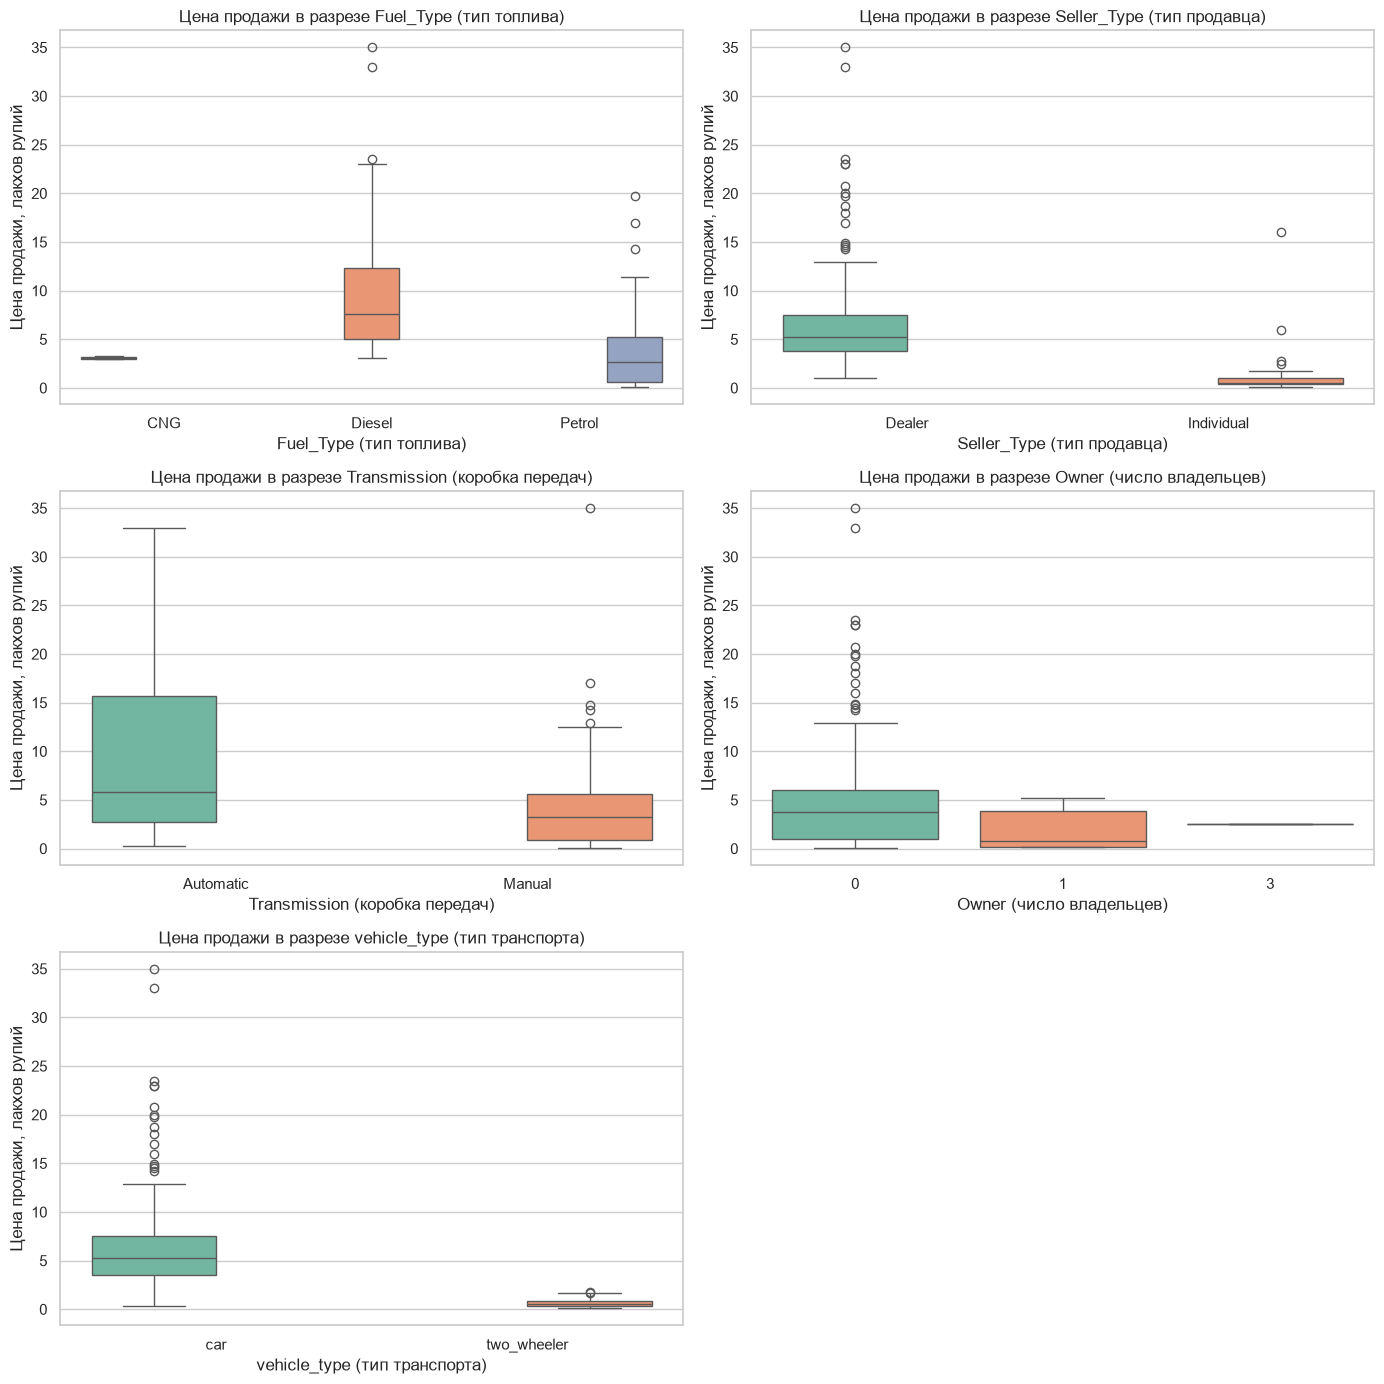

In [21]:
cat_to_plot = ['Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'vehicle_type']
fig, axes = plt.subplots(3, 2, figsize=(14, 14))
axes = axes.flatten()

for ax, col in zip(axes, cat_to_plot):
    sns.boxplot(data=df, x=col, y=target, ax=ax, hue=col,
                palette='Set2', legend=False)
    ax.set_title(f'Цена продажи в разрезе {ru(col)}')
    ax.set_ylabel('Цена продажи, лакхов рупий')
    ax.set_xlabel(ru(col))

axes[-1].axis('off')
plt.tight_layout()
plt.savefig('price_by_category.png', dpi=120)
plt.show()

In [22]:
for col in cat_to_plot:
    stat = df.groupby(col, observed=True).agg(
        кол_во=(target, 'size'),
        цена_продажи=(target, 'mean'),
        цена_нового=('Present_Price', 'mean'),
        сохранность=('depreciation', 'mean'),
    ).round(2)
    print(f'--- {ru(col)} ---')
    print(stat.to_string(), end='\n\n')

--- Fuel_Type (тип топлива) ---
           кол_во  цена_продажи  цена_нового  сохранность
Fuel_Type                                                
CNG             2          3.10         6.42         0.51
Diesel         58         10.10        15.65         0.68
Petrol        237          3.29         5.62         0.63

--- Seller_Type (тип продавца) ---
             кол_во  цена_продажи  цена_нового  сохранность
Seller_Type                                                
Dealer          193          6.63        10.78         0.64
Individual      104          0.88         1.65         0.63

--- Transmission (коробка передач) ---
              кол_во  цена_продажи  цена_нового  сохранность
Transmission                                                
Automatic         38          9.31        15.30         0.64
Manual           259          3.93         6.45         0.63

--- Owner (число владельцев) ---
       кол_во  цена_продажи  цена_нового  сохранность
Owner                         

In [23]:
print('Тип транспорта в разрезе продавца:')
print(pd.crosstab(df['Seller_Type'], df['vehicle_type']).to_string())

Тип транспорта в разрезе продавца:
vehicle_type  car  two_wheeler
Seller_Type                   
Dealer        193            0
Individual      6           98


### Вывод

- Самое заметное различие даёт `Seller_Type`: средняя цена у салонов 6.63 лакха,
  у частников — 0.88, разрыв в 7.5 раза. Но это **ложная зависимость**: таблица
  сопряжённости показывает, что салоны продают 193 автомобиля и ни одного мотоцикла,
  а частники — 98 мотоциклов и всего 6 автомобилей. `Seller_Type` здесь почти
  полностью дублирует `vehicle_type`.
- Подтверждение: коэффициент сохранения стоимости у обеих групп одинаков —
  0.64 у салонов против 0.63 у частников. То есть тип продавца не влияет на то,
  сколько лот теряет в цене; он лишь указывает, **что** продаётся.
- Та же логика с `Fuel_Type`: дизель дороже бензина (10.10 против 3.29), но и
  цена нового у дизельных выше (15.65 против 5.62). По сохранности разрыв гораздо
  скромнее: 0.68 против 0.63.
- `Transmission`: автоматы дороже (9.31 против 3.93), сохранность при этом
  одинаковая (0.64 и 0.63) — снова эффект сегмента, а не самой коробки.
- `Owner`: переход от нуля к одному прошлому владельцу снижает сохранность
  с 0.64 до 0.46 — вот это уже реальный ценовой фактор. Категория `Owner = 3`
  представлена единственной записью и для выводов непригодна.

## 3.5 Кривая амортизации

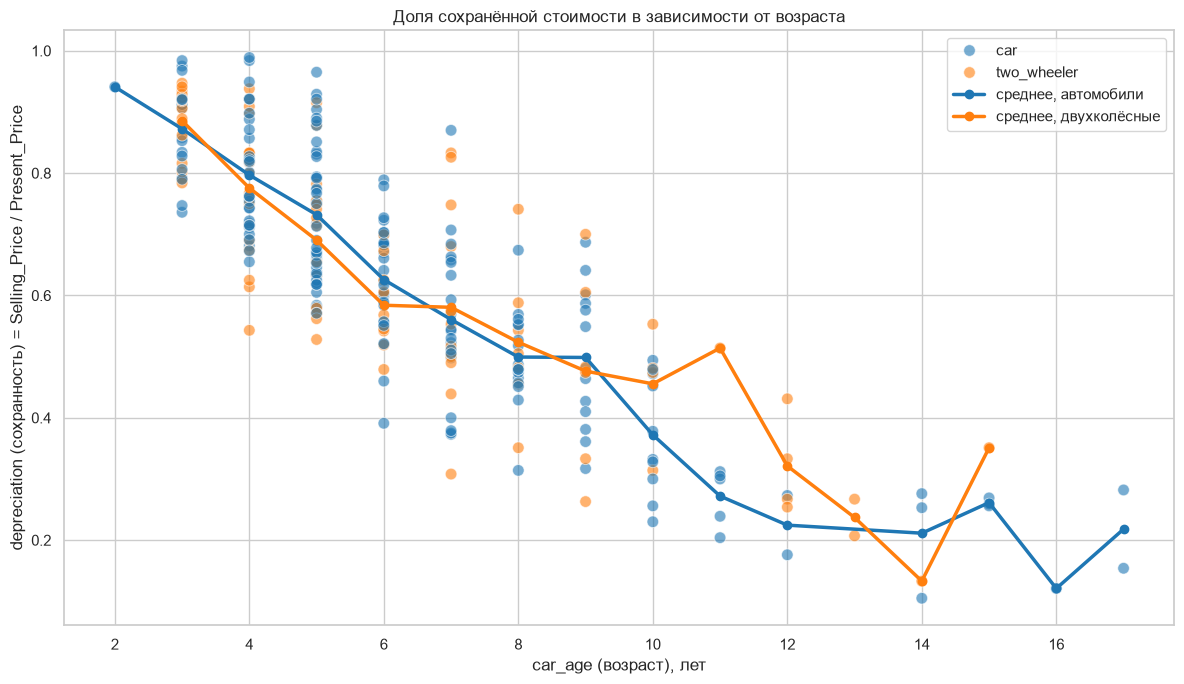

In [24]:
cars = df[df['vehicle_type'] == 'car']
bikes = df[df['vehicle_type'] == 'two_wheeler']

plt.figure(figsize=(12, 7))
sns.scatterplot(data=df, x='car_age', y='depreciation', hue='vehicle_type',
                palette={'car': '#1f77b4', 'two_wheeler': '#ff7f0e'},
                s=70, alpha=.6)

for subset, color, label in [(cars, '#1f77b4', 'автомобили'),
                             (bikes, '#ff7f0e', 'двухколёсные')]:
    trend = subset.groupby('car_age', observed=True)['depreciation'].mean()
    plt.plot(trend.index, trend.values, color=color, lw=2.5,
             marker='o', label=f'среднее, {label}')

plt.title('Доля сохранённой стоимости в зависимости от возраста')
plt.xlabel('car_age (возраст), лет')
plt.ylabel('depreciation (сохранность) = Selling_Price / Present_Price')
plt.legend()
plt.tight_layout()
plt.savefig('depreciation_curve.png', dpi=120)
plt.show()

In [25]:
print('Средняя сохранность стоимости по возрасту (автомобили):')
print(cars.groupby('car_age', observed=True)['depreciation']
          .agg(['mean', 'size']).round(3).to_string())

Средняя сохранность стоимости по возрасту (автомобили):
          mean  size
car_age             
2        0.941     1
3        0.872    19
4        0.797    30
5        0.732    45
6        0.626    29
7        0.561    20
8        0.499    16
9        0.499    13
10       0.372    10
11       0.272     5
12       0.224     2
14       0.211     3
15       0.261     3
16       0.121     1
17       0.218     2


### Вывод

- Зависимость близка к линейной, а не экспоненциальной: у автомобилей сохранность
  падает с 0.87 на третий год до 0.37 на десятый — около 7 процентных пунктов в год.
- После 11–12 лет кривая выполаживается в районе 0.2–0.27: дальше транспорт
  почти не дешевеет.
- Двухколёсные теряют стоимость по той же траектории, что и автомобили — средняя
  сохранность у них 0.65 против 0.63. Несмотря на разницу в абсолютных ценах
  на два порядка, механика амортизации одинаковая.
- Разброс вокруг кривой большой (±0.2), то есть возраст объясняет лишь часть
  вариации: остальное — состояние, пробег, число владельцев.

## 3.6 Влияние пробега на цену

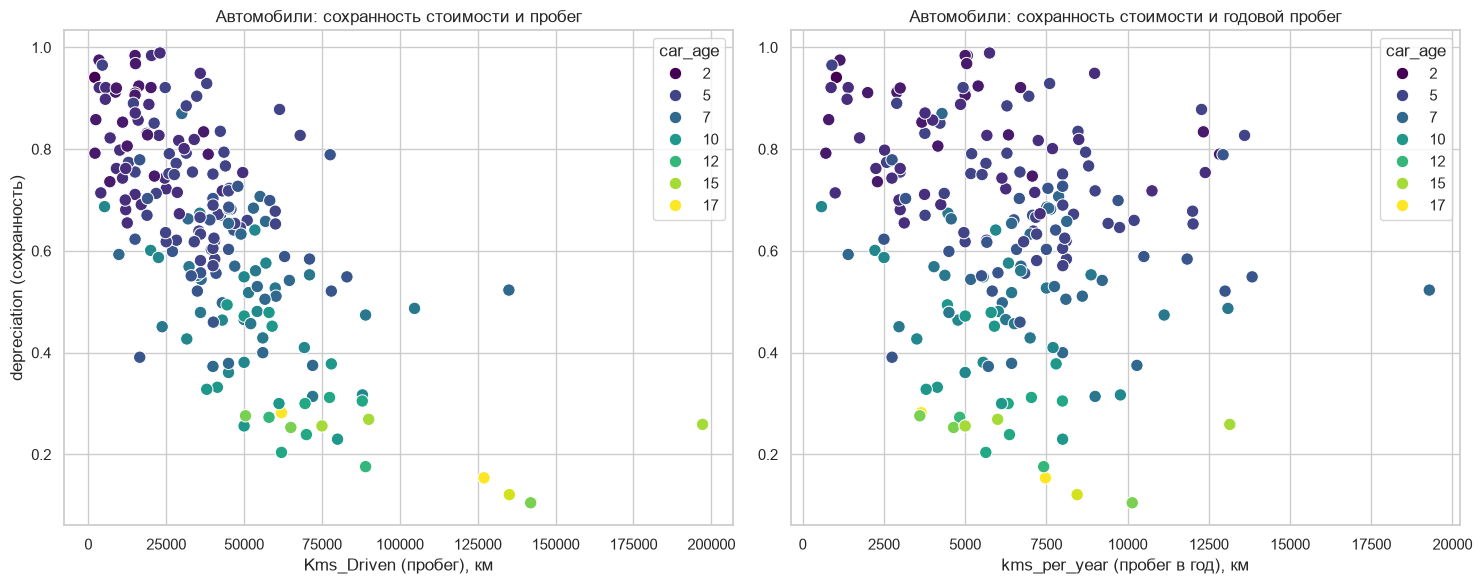

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=cars, x='Kms_Driven', y='depreciation', hue='car_age',
                palette='viridis', s=80, ax=axes[0])
axes[0].set_title('Автомобили: сохранность стоимости и пробег')
axes[0].set_xlabel('Kms_Driven (пробег), км')
axes[0].set_ylabel('depreciation (сохранность)')

sns.scatterplot(data=cars, x='kms_per_year', y='depreciation', hue='car_age',
                palette='viridis', s=80, ax=axes[1])
axes[1].set_title('Автомобили: сохранность стоимости и годовой пробег')
axes[1].set_xlabel('kms_per_year (пробег в год), км')
axes[1].set_ylabel('')

plt.tight_layout()
plt.savefig('kms_vs_price.png', dpi=120)
plt.show()

In [27]:
print('Корреляция сохранности стоимости (только автомобили):')
print(ru_frame(cars[['depreciation', 'Kms_Driven', 'kms_per_year', 'car_age']]
               .corr()['depreciation'].drop('depreciation').round(3)).to_string())

Корреляция сохранности стоимости (только автомобили):
Kms_Driven (пробег)           -0.686
kms_per_year (пробег в год)   -0.205
car_age (возраст)             -0.856


### Вывод

- У автомобилей сохранность стоимости уверенно падает с ростом пробега: корреляция
  `depreciation` с `Kms_Driven` равна −0.686. Но самый сильный фактор — всё-таки
  возраст: −0.856.
- Цветовая шкала подтверждает, что большой пробег и большой возраст почти всегда
  идут вместе (их взаимная корреляция у автомобилей 0.708) — признаки частично
  дублируют друг друга.
- Годовой пробег `kms_per_year` (правый график) на сохранность стоимости влияет
  слабо: корреляция всего −0.205, облако точек почти бесструктурное. Вместе
  с разделом 3.3 это даёт итоговую трактовку: положительная связь `kms_per_year`
  с абсолютной ценой (0.321) — не влияние пробега, а артефакт сегмента
  (дорогие машины больше ездят). **Обесценивает лот именно суммарный пробег,
  а не интенсивность езды.**

# 4. Сохранение финального датасета

In [28]:
df_final = df.drop(columns=['Car_Name', 'depreciation'])

print('Удалены столбцы: Car_Name, depreciation')
print('Итоговый размер выборки:', df_final.shape)
print('Столбцы:', list(df_final.columns))
df_final.head()

Удалены столбцы: Car_Name, depreciation
Итоговый размер выборки: (297, 11)
Столбцы: ['Year', 'Selling_Price', 'Present_Price', 'Kms_Driven', 'Fuel_Type', 'Seller_Type', 'Transmission', 'Owner', 'vehicle_type', 'car_age', 'kms_per_year']


,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner,vehicle_type,car_age,kms_per_year
0,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0,car,6,4500
1,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0,car,7,6143
2,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0,car,3,2300
3,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0,car,9,578
4,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0,car,6,7075


Из финальной выборки удалены два столбца:

- `Car_Name` — 98 уникальных значений на 297 записей. Кодировать такой признак
  нечем: при One-Hot получится 98 почти пустых столбцов, при Target Encoding
  среднее будет считаться по 3 наблюдениям. Полезную информацию из него уже
  извлекли в виде признака `vehicle_type`.
- `depreciation` — вычислен через целевую переменную, использовать в модели
  нельзя (target leakage). Свою роль в анализе он уже отыграл.

In [29]:
with open('../data/clean_data.pkl', 'wb') as f:
    pickle.dump(df_final, f)

print('Датасет сохранён в ../data/clean_data.pkl')
print()
print(df_final.dtypes.to_string())

Датасет сохранён в ../data/clean_data.pkl

Year                int16
Selling_Price     float64
Present_Price     float64
Kms_Driven          int32
Fuel_Type        category
Seller_Type      category
Transmission     category
Owner                int8
vehicle_type     category
car_age              int8
kms_per_year        int32


Формат `pickle` выбран потому, что сохраняет типы данных столбцов: признаки типа
`category` и пониженная разрядность целых не пережили бы сохранение в CSV
и их пришлось бы восстанавливать вручную.

# 5. Выводы

## Что сделано при очистке данных

1. Удалены 2 полностью дублирующиеся записи (301 → 299).
2. Обнаружено, что датасет содержит не только автомобили, но и мотоциклы со
   скутерами. По названию модели записи размечены признаком `vehicle_type`:
   199 автомобилей и 100 единиц двухколёсной техники.
3. Удалены 2 физически неправдоподобные записи: скутер Honda Activa 3g с пробегом
   500 000 км и мотоцикл Honda Karizma с 213 000 км. От формального критерия
   «выброс = 1.5 IQR» отказались сознательно — он удалял корректные записи
   (Toyota Fortuner с пробегом 135 000 км). Итоговый размер — **297 записей**.
4. Пропущенных значений в датасете нет, восстанавливать ничего не потребовалось.
5. Проверено, что `Selling_Price` нигде не превышает `Present_Price` — противоречий нет.
6. Типы данных приведены: номинальные признаки к `category`, `Owner` и `car_age`
   к `int8`, `Year` к `int16`, `Kms_Driven` и `kms_per_year` к `int32`.
7. Перед сохранением удалены `Car_Name` (98 уникальных значений — не кодируется)
   и `depreciation` (утечка целевой переменной).

## Созданные признаки

- `vehicle_type` — автомобиль или двухколёсный транспорт, выделен из `Car_Name`.
- `car_age` — возраст в годах (`2020 - Year`).
- `kms_per_year` — годовой пробег (`Kms_Driven / car_age`).
- `depreciation` — доля сохранённой стоимости (`Selling_Price / Present_Price`).
  Создан **только для анализа** и в финальную выборку не включён из-за утечки
  целевой переменной.

## Выявленные закономерности

- `Present_Price` — доминирующий предиктор: корреляция с ценой продажи 0.876,
  у всех остальных признаков она ниже 0.33 (см. `correlation.png`).
  В логарифмических координатах связь близка к линейной (см. `price_scatter.html`).
- **`Seller_Type` — ложный признак.** Разрыв средних цен в 7.5 раза (6.63 против 0.88)
  объясняется не типом продавца, а тем, что салоны продают 193 автомобиля и ноль
  мотоциклов, а частники — 98 мотоциклов и 6 автомобилей. Сохранность стоимости
  у обеих групп одинакова: 0.64 и 0.63 (см. `price_by_category.png`).
- Тот же эффект сегмента у `Fuel_Type` и `Transmission`: дизель и автомат «дороже»
  только потому, что это более дорогие модели в новом состоянии.
- Реальный ценовой фактор среди категориальных признаков — `Owner`: один предыдущий
  владелец снижает сохранность стоимости с 0.64 до 0.46. Сильнейший же фактор
  обесценивания — возраст: корреляция с сохранностью −0.856.
- Амортизация линейна: около 6 процентных пунктов стоимости в год, с выполаживанием
  после 11–12 лет на уровне 0.2–0.27 (см. `depreciation_curve.png`).
  У двухколёсных траектория та же, что у автомобилей.
- На сохранность стоимости влияет суммарный пробег (корреляция −0.686 у автомобилей),
  а не интенсивность езды (`kms_per_year`, всего −0.205). Положительная корреляция
  `kms_per_year` с абсолютной ценой (0.321) — артефакт сегмента: дорогие машины
  больше ездят (см. `kms_vs_price.png`).
- Целевая переменная скошена вправо (асимметрия 2.53); логарифмирование приводит
  её к 0.11 (см. `target_distribution.png`). Обучать регрессию имеет смысл
  на логарифме цены.
- `Year` и `car_age` дублируют друг друга (корреляция −1.00) — в модель подаём один.

Обработанная выборка сохранена в файл `../data/clean_data.pkl`.